In [28]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer
from qiskit import *
from qiskit.visualization import plot_histogram, plot_bloch_multivector, array_to_latex
from math import pi
%matplotlib inline

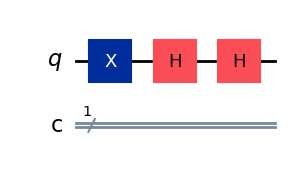

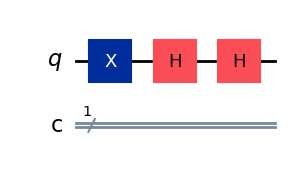

In [29]:
circuit = QuantumCircuit(1, 1)
circuit.x(0)
circuit.h(0)
circuit.h(0)
circuit.draw('mpl')

In [30]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit).result()
statevector = result.get_statevector()
# print(statevector)
array_to_latex(statevector, prefix="\\text{statevector = }\n") # , pretext="|\\psi\\rangle = ")

<IPython.core.display.Latex object>

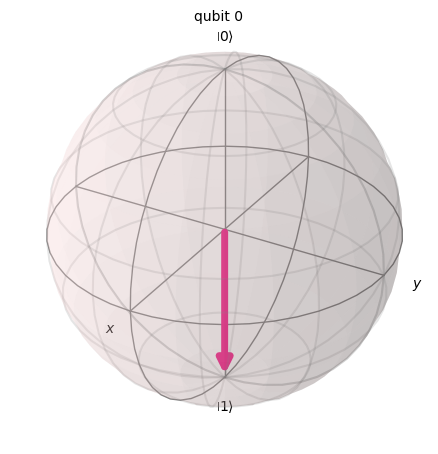

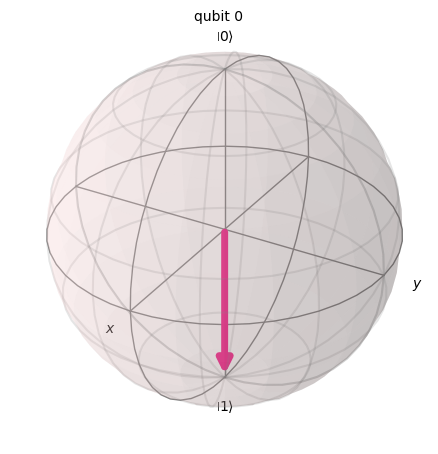

In [31]:
plot_bloch_multivector(statevector)

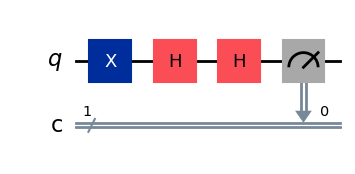

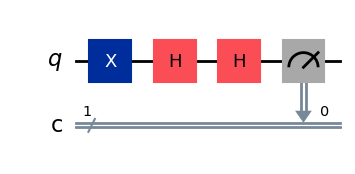

In [32]:
circuit.measure(0, 0)
circuit.draw('mpl')

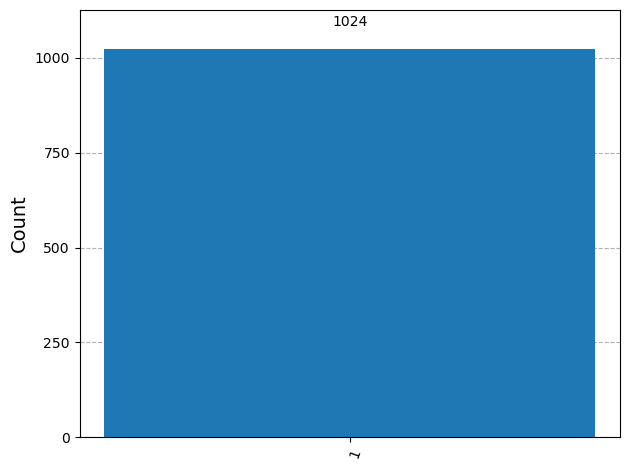

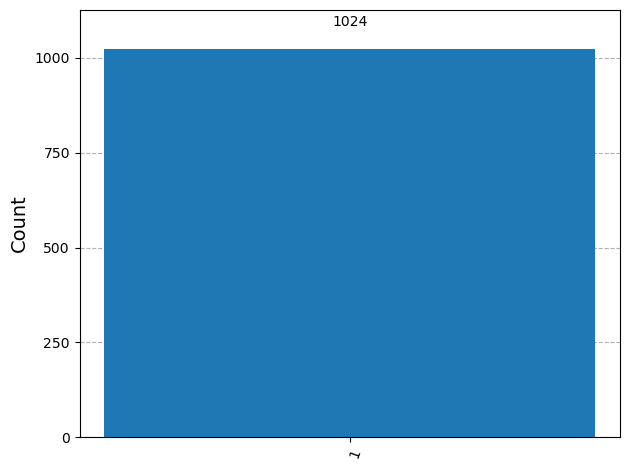

In [33]:
qasm_simulator = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(circuit, backend=qasm_simulator)
result = qasm_simulator.run(compiled_circuit, shots=1024).result()
plot_histogram(result.get_counts())